# CKD-NHANES 2021-2023: Análisis exploratorio

Dataset real del CDC **NHANES 2021-2023** (~11,933 participantes) para detectar
**Enfermedad Renal Crónica (CKD)** a partir de variables clínicas y de laboratorio,
con estadificación KDIGO 2024 y eGFR (CKD-EPI 2021).

- **Objetivo binario**: `ckd_present` (0 = sin CKD, 1 = CKD)
- **Objetivo multi-clase**: `ckd_stage` (No CKD / G1 / G2 / G3a / G3b / G4 / G5)
- **Fuente**: CDC NHANES, `alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease` (CC0)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [3]:
from pathlib import Path
DATA = Path("data/CKD_NHANES_2021_2023.csv")
if not DATA.exists():
    DATA = Path("../data/CKD_NHANES_2021_2023.csv")
df = pd.read_csv(DATA)
df.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


## Dimensiones y tipos de datos

In [4]:
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
df.info()

Filas: 11,933  |  Columnas: 29
<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  str    
 3   ethnicity                 11933 non-null  str    
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null  

## Variable objetivo (CKD vs no CKD)

ckd_present
0    3592
1    8341
Name: count, dtype: int64

Prevalencia de CKD: 69.9%


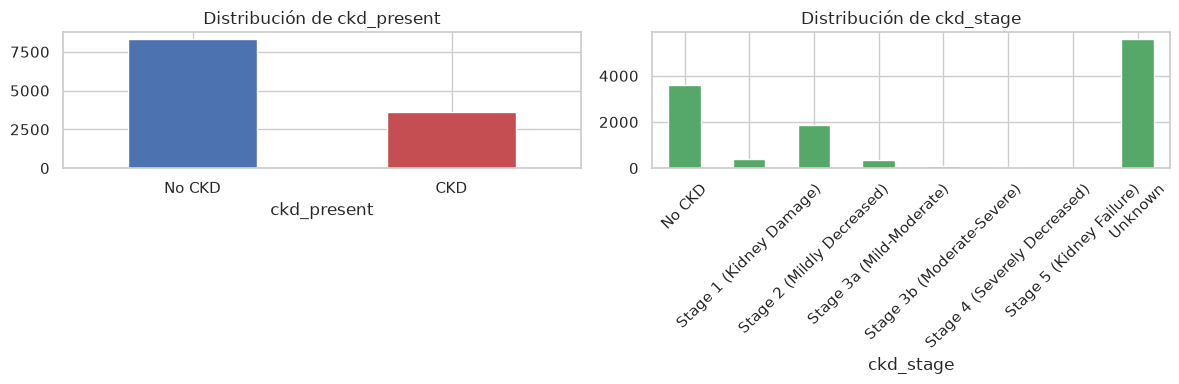

In [5]:
print(df["ckd_present"].value_counts().sort_index())
print(f"\nPrevalencia de CKD: {df['ckd_present'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["ckd_present"].value_counts().plot(kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_title("Distribución de ckd_present")
axes[0].set_xticklabels(["No CKD", "CKD"], rotation=0)

df["ckd_stage"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55a868")
axes[1].set_title("Distribución de ckd_stage")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Valores faltantes

El dataset tiene muchos valores ausentes (típico de encuestas NHANES). Esto
condicionará el preprocesamiento (imputación).

                     Faltantes     %
insulin_use              10852  90.9
diabetes_pills            9652  80.9
current_smoker            8690  72.8
phosphorus                5611  47.0
bicarbonate               5608  47.0
blood_urea_nitrogen       5607  47.0
serum_creatinine          5607  47.0
egfr                      5607  47.0
uric_acid                 5604  47.0
calcium                   5571  46.7
albumin_serum             5567  46.7
bp_diastolic              4416  37.0
bp_systolic               4416  37.0
education_level           4139  34.7
ever_smoked               3798  31.8


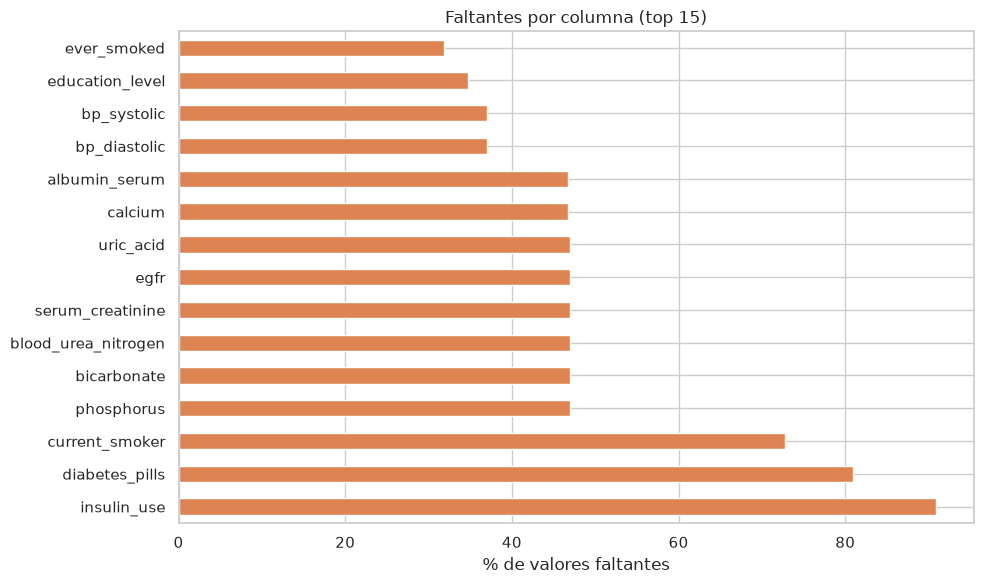

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
miss = pd.DataFrame({"Faltantes": missing, "%": missing_pct}).head(15)
print(miss)

fig, ax = plt.subplots(figsize=(10, 6))
miss["%"].plot(kind="barh", ax=ax, color="#dd8452")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Faltantes por columna (top 15)")
plt.tight_layout()
plt.show()

## Distribuciones de variables clave por grupo (CKD vs no CKD)

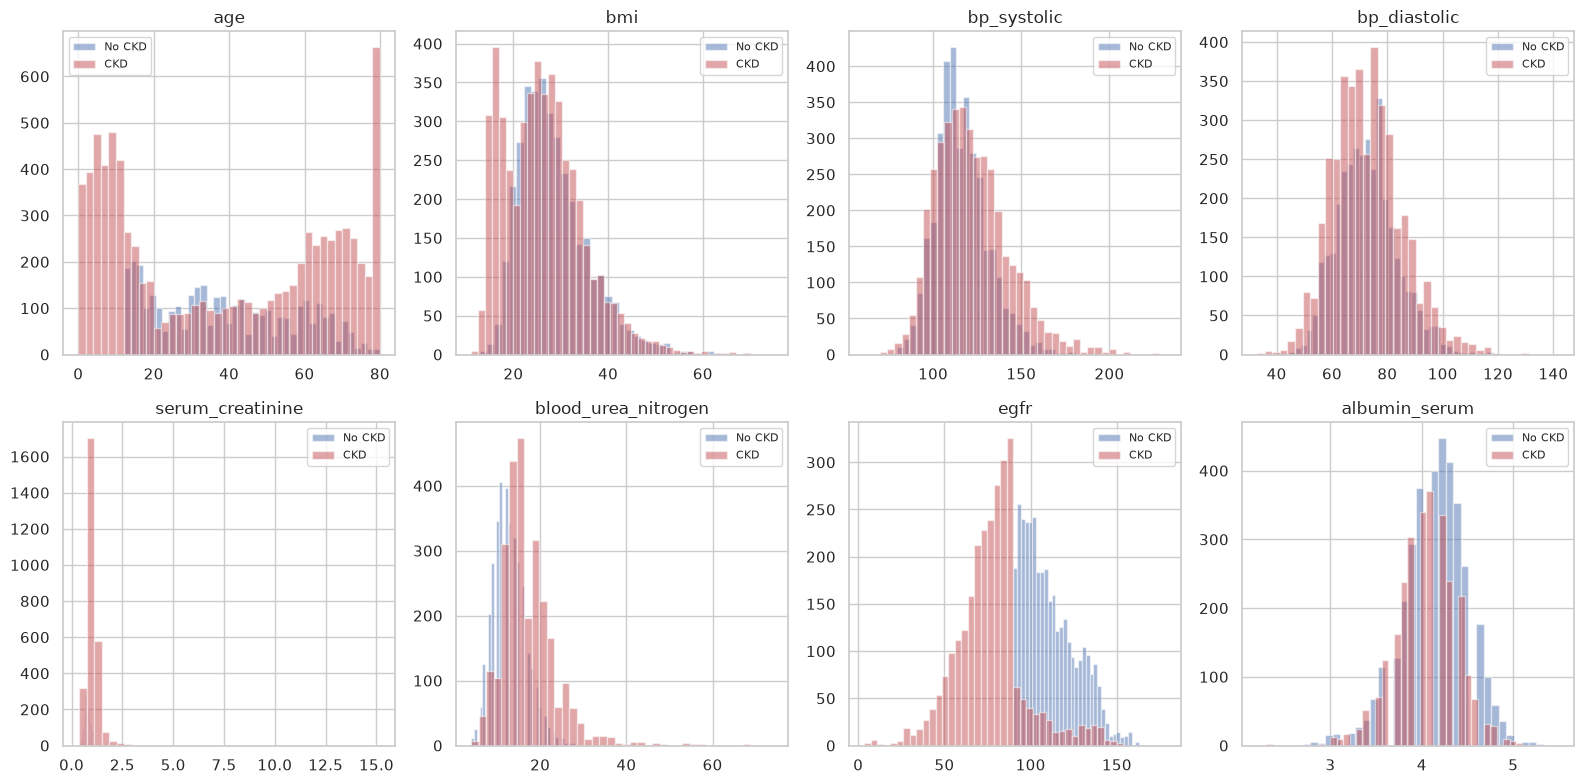

In [7]:
lab_vars = ["age", "bmi", "bp_systolic", "bp_diastolic",
            "serum_creatinine", "blood_urea_nitrogen", "egfr",
            "albumin_serum", "uric_acid", "phosphorus"]

lab_vars = [c for c in lab_vars if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, var in zip(axes, lab_vars):
    for val, color in [(0, "#4c72b0"), (1, "#c44e52")]:
        sub = df[df["ckd_present"] == val][var].dropna()
        ax.hist(sub, bins=40, alpha=0.5, label=f"{'No CKD' if val==0 else 'CKD'}", color=color)
    ax.set_title(var)
    ax.legend(fontsize=8)
for ax in axes[len(lab_vars):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Correlaciones (variables numéricas)

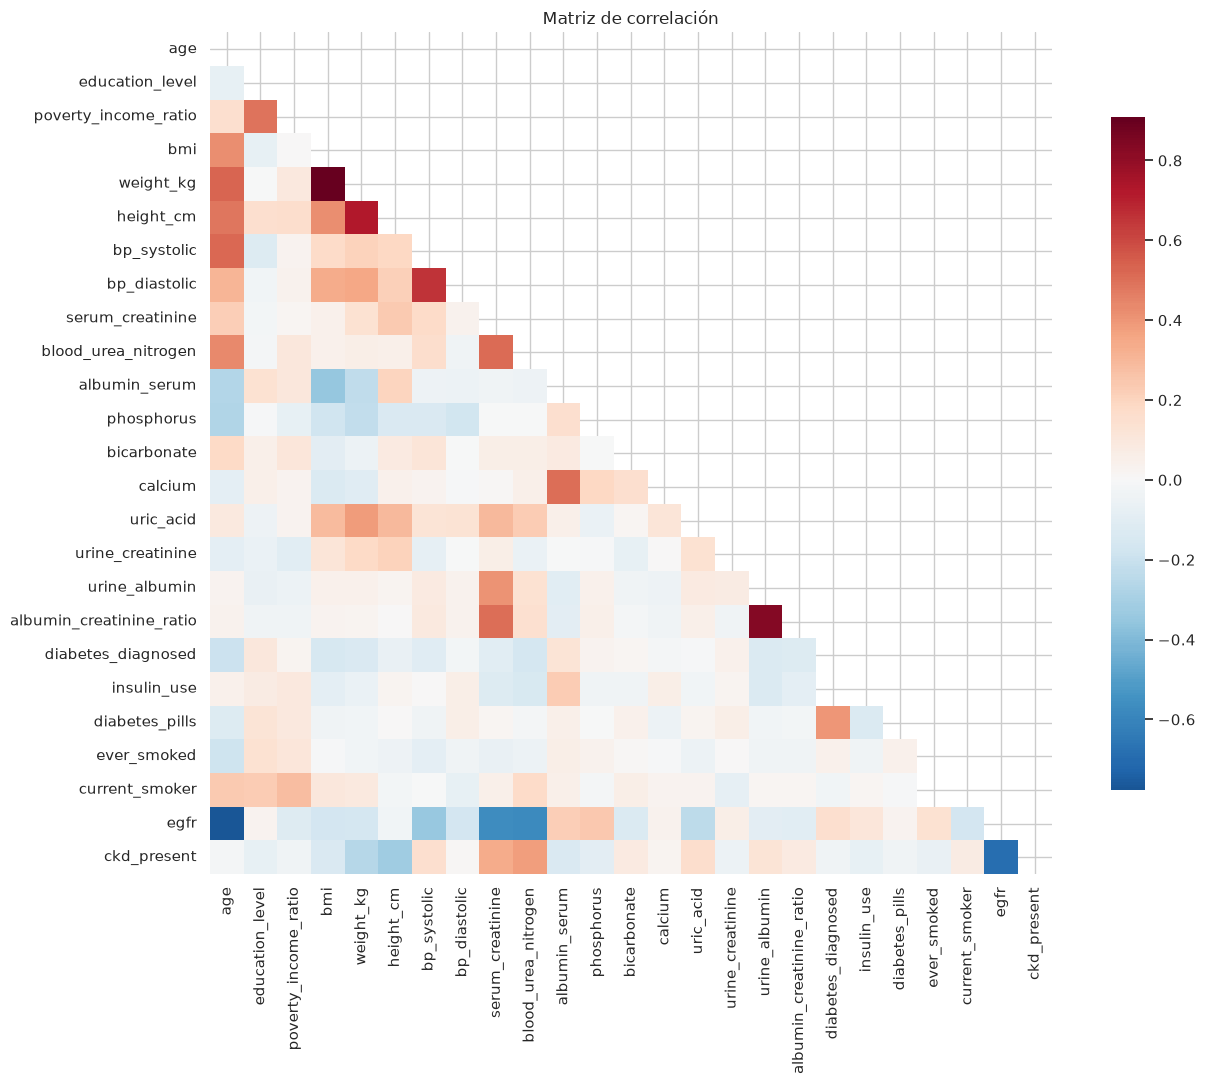

In [8]:
num = df.select_dtypes(include=[np.number]).drop(columns=["participant_id"], errors="ignore")
corr = num.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [9]:
print("Correlación de cada variable con ckd_present:")
print(num.corr()["ckd_present"].drop("ckd_present").sort_values(ascending=False).round(3))

Correlación de cada variable con ckd_present:
blood_urea_nitrogen         0.377
serum_creatinine            0.343
uric_acid                   0.163
bp_systolic                 0.153
urine_albumin               0.120
albumin_creatinine_ratio    0.086
bicarbonate                 0.085
current_smoker              0.079
calcium                     0.023
bp_diastolic                0.009
age                        -0.015
diabetes_pills             -0.037
diabetes_diagnosed         -0.040
poverty_income_ratio       -0.043
urine_creatinine           -0.056
ever_smoked                -0.071
insulin_use                -0.074
education_level            -0.074
phosphorus                 -0.096
bmi                        -0.139
albumin_serum              -0.144
weight_kg                  -0.259
height_cm                  -0.316
egfr                       -0.687
Name: ckd_present, dtype: float64


## Clustermap: top 10 variables por correlación con ckd_present

Se seleccionan las **10 variables numéricas** con mayor |correlación absoluta|
respecto a la variable objetivo `ckd_present` y se genera un **clustermap** con
dendrogramas de filas y columnas para agrupar variables y pacientes similares.

Top 10 variables por |correlación| con ckd_present:
egfr                   0.687
blood_urea_nitrogen    0.377
serum_creatinine       0.343
height_cm              0.316
weight_kg              0.259
uric_acid              0.163
bp_systolic            0.153
albumin_serum          0.144
bmi                    0.139
urine_albumin          0.120
Name: ckd_present, dtype: float64


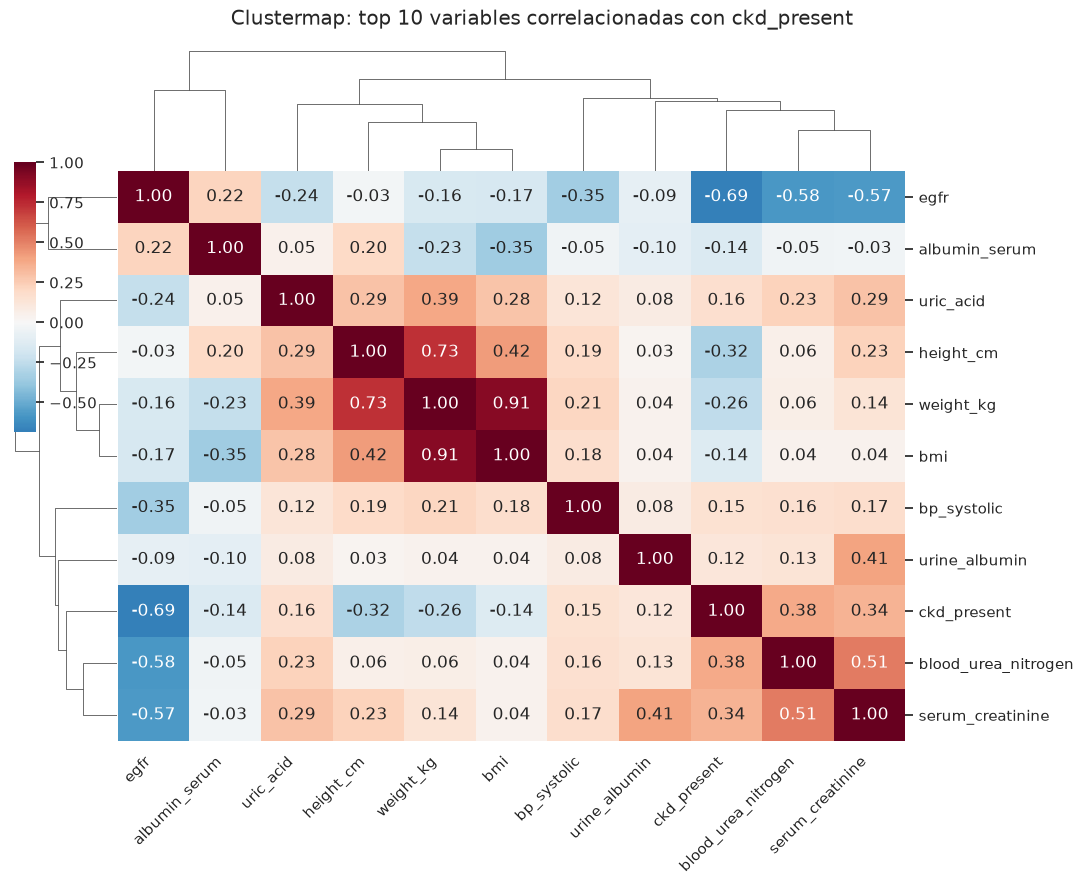

In [10]:
num = df.select_dtypes(include=[np.number]).drop(columns=["participant_id"], errors="ignore")
corr = num.corr()

abs_corr = corr["ckd_present"].drop("ckd_present").abs().sort_values(ascending=False)
top10 = abs_corr.head(10)
print("Top 10 variables por |correlación| con ckd_present:")
print(top10.round(3))

sel = num[top10.index].copy()
sel["ckd_present"] = df["ckd_present"]

g = sns.clustermap(
    sel.corr(),
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    figsize=(11, 9),
    dendrogram_ratio=(0.12, 0.18),
    cbar_pos=(0.02, 0.55, 0.02, 0.3),
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.fig.suptitle("Clustermap: top 10 variables correlacionadas con ckd_present", y=1.02)
plt.show()

## PCA: reducción de dimensionalidad y variables relevantes

**PCA** (Análisis de Componentes Principales) proyecta los datos sobre ejes ortogonales que maximizan la varianza. Cada componente es una **combinación lineal** de las variables originales, por lo que sus **loadings** (pesos) revelan qué variables aportan más a la estructura de los datos.

- Con variables en unidades muy distintas (creatinina ~1, peso ~80, eGFR ~90) **es obligatorio estandarizar** antes de aplicar PCA.
- Complementa la sección anterior: la **correlación** se enfoca en la relación con el objetivo `ckd_present`; **PCA** se enfoca en la estructura de varianza de todo el dataset.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["participant_id", "ckd_present"]]

X = df[num_cols].copy()
X = X.fillna(X.median())
print(f"Matriz para PCA: {X.shape[0]} filas x {X.shape[1]} features (NaN imputados con mediana)")

Matriz para PCA: 11933 filas x 24 features (NaN imputados con mediana)


### Aportación de varianza (PCA completo)

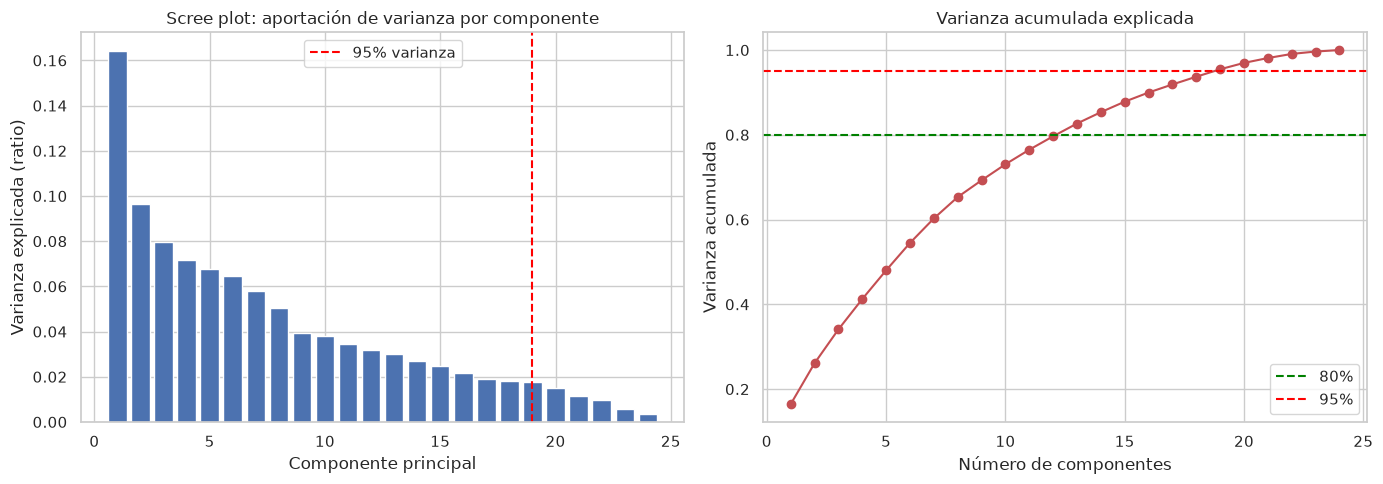

Componentes para 80% de varianza: 13
Componentes para 95% de varianza: 19


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA().fit(X_scaled)
evr = pca.explained_variance_ratio_
cum = evr.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(evr) + 1), evr, color="#4c72b0")
axes[0].axvline(x=len([c for c in cum if c < 0.95]) + 1, color="red", ls="--", label="95% varianza")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (ratio)")
axes[0].set_title("Scree plot: aportación de varianza por componente")
axes[0].legend()

# Varianza acumulada
axes[1].plot(range(1, len(cum) + 1), cum, marker="o", color="#c44e52")
axes[1].axhline(y=0.80, color="green", ls="--", label="80%")
axes[1].axhline(y=0.95, color="red", ls="--", label="95%")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza acumulada explicada")
axes[1].legend()
plt.tight_layout()
plt.show()

n80 = (cum < 0.80).sum() + 1
n95 = (cum < 0.95).sum() + 1
print(f"Componentes para 80% de varianza: {n80}")
print(f"Componentes para 95% de varianza: {n95}")

### Variables relevantes: loadings de PC1 y PC2

Los loadings muestran el peso de cada variable original en cada componente. Un |loading| alto indica que la variable contribuye fuertemente a esa dirección de máxima varianza.

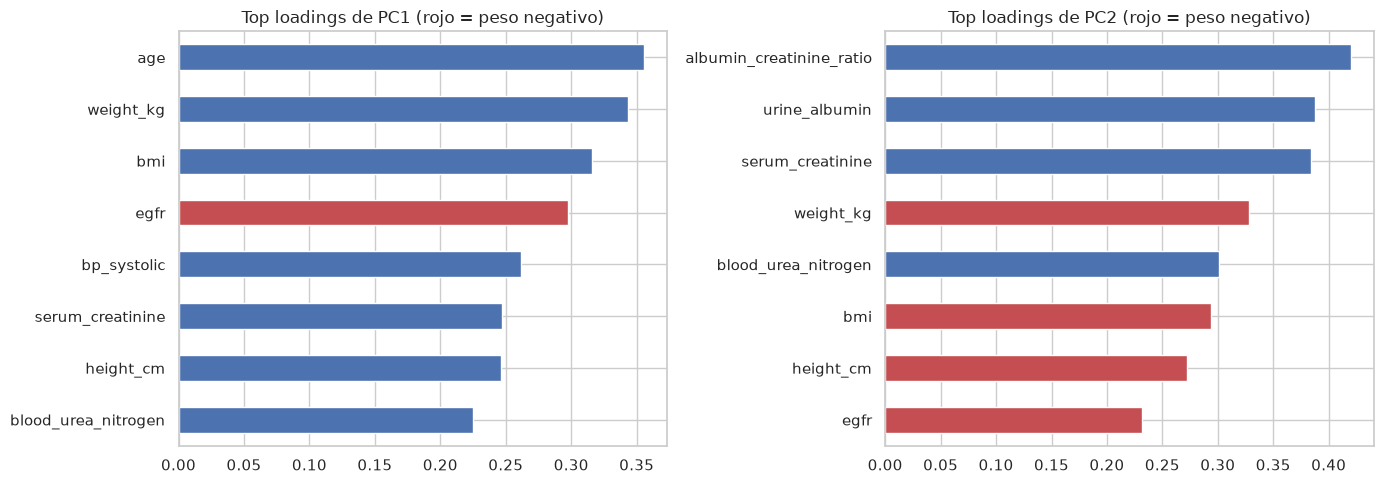


Top 8 loadings |PC1|:
age                    0.356
weight_kg              0.343
bmi                    0.316
egfr                   0.298
bp_systolic            0.261
serum_creatinine       0.247
height_cm              0.246
blood_urea_nitrogen    0.225
Name: PC1, dtype: float64

Top 8 loadings |PC2|:
albumin_creatinine_ratio    0.420
urine_albumin               0.387
serum_creatinine            0.384
weight_kg                   0.328
blood_urea_nitrogen         0.301
bmi                         0.294
height_cm                   0.272
egfr                        0.232
Name: PC2, dtype: float64


In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
    index=num_cols,
)

def top_loadings(comp: str, n: int = 8) -> pd.Series:
    return loadings[comp].abs().sort_values(ascending=False).head(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, comp in zip(axes, ["PC1", "PC2"]):
    tl = top_loadings(comp)
    colors = ["#c44e52" if loadings.loc[v, comp] < 0 else "#4c72b0" for v in tl.index]
    tl.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(f"Top loadings de {comp} (rojo = peso negativo)")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 8 loadings |PC1|:"); print(top_loadings("PC1").round(3))
print("\nTop 8 loadings |PC2|:"); print(top_loadings("PC2").round(3))

### Proyección PC1 vs PC2 coloreada por ckd_present

Visualiza si la estructura 2D separa naturalmente pacientes con y sin CKD.

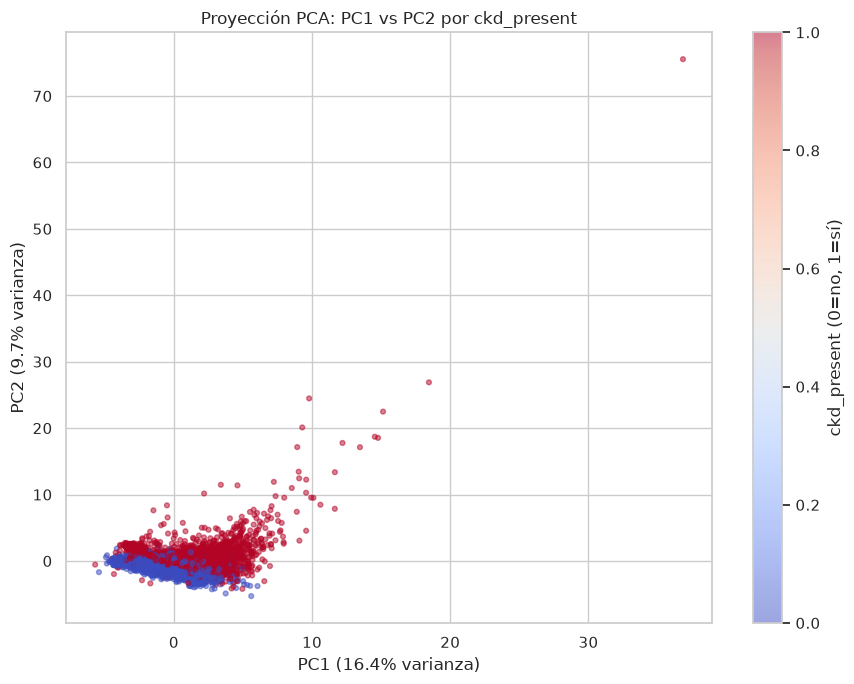

In [14]:
scores = pca.transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(scores[:, 0], scores[:, 1], c=df["ckd_present"],
                cmap="coolwarm", s=12, alpha=0.5)
ax.set_xlabel(f"PC1 ({evr[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({evr[1]:.1%} varianza)")
ax.set_title("Proyección PCA: PC1 vs PC2 por ckd_present")
plt.colorbar(sc, label="ckd_present (0=no, 1=sí)")
plt.tight_layout()
plt.show()

### Variante sin eGFR

`egfr` está matemáticamente ligado a creatinina/urea y domina la varianza. Se repite PCA **excluyendo `egfr`** para evaluar si la reducción de dimensionalidad sigue siendo útil con variables accesibles en un tamizaje sin el marcador derivado.

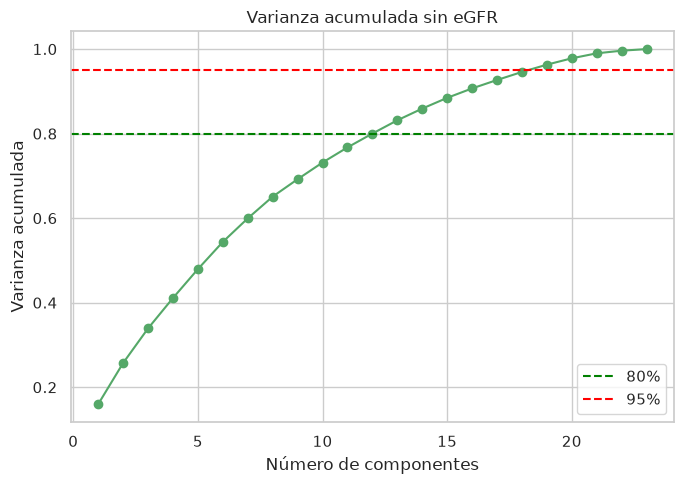

Con eGFR:    13 comps -> 80%, 19 comps -> 95%
Sin eGFR:    12 comps -> 80%, 19 comps -> 95%


In [17]:
cols_no_egfr = [c for c in num_cols if c != "egfr"]
X2 = df[cols_no_egfr].fillna(df[cols_no_egfr].median())
X2_scaled = scaler.fit_transform(X2)

pca2 = PCA().fit(X2_scaled)
evr2 = pca2.explained_variance_ratio_
cum2 = evr2.cumsum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1, len(cum2) + 1), cum2, marker="o", color="#55a868")
ax.axhline(y=0.80, color="green", ls="--", label="80%")
ax.axhline(y=0.95, color="red", ls="--", label="95%")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza acumulada")
ax.set_title("Varianza acumulada sin eGFR")
ax.legend()
plt.tight_layout()
plt.show()

n80_2 = (cum2 < 0.80).sum() + 1
n95_2 = (cum2 < 0.95).sum() + 1
print(f"Con eGFR:    {n80} comps -> 80%, {n95} comps -> 95%")
print(f"Sin eGFR:    {n80_2} comps -> 80%, {n95_2} comps -> 95%")

## Resumen

- **11,933 participantes**, 29 columnas (clínicas, laboratorio, estilo de vida).
- Objetivo binario `ckd_present` (con prevalencia reportada arriba) y multi-clase `ckd_stage`.
- **Muchos valores faltantes** en marcadores de laboratorio → requerirá imputación.
- `egfr` y `ckd_stage` derivan de creatinina/albúmina: conviene analizar cuáles variables
  discriminan mejor y qué ocurre al excluir `egfr` (tamizaje realista).
